# Title:
# IMDB Dataset Data Cleaning and Preprocessing

Statement:
This project demonstrates the end-to-end process of cleaning a messy IMDB dataset by handling missing values, correcting inconsistencies, converting data types, and preparing the data for analysis and machine learning.

# step 1: Data Cleaning Checklist

1. Missing values

2. Duplicate rows

3. Spelling errors / wrong text

4. Outliers

5. Incorrect data types

6. Inconsistent formatting

7. Column name cleaning

8. Wrong symbols inside numbers
9. Date format correction

10. Save final cleaned dataset

# step 2. Data Loading

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('messy_IMDB_dataset.csv', encoding='cp1252', sep=';')
df.head()

,IMBD title ID,Original titlÊ,Release year,Genrë¨,Duration,Country,Content Rating,Director,Unnamed: 8,Income,Votes,Score
0,tt0111161,The Shawshank Redemption,1995-02-10,Drama,142,USA,R,Frank Darabont,NaN,$ 28815245,2.278.845,9.3
1,tt0068646,The Godfather,09 21 1972,"Crime, Drama",175,USA,R,Francis Ford Coppola,NaN,$ 246120974,1.572.674,9.2
2,tt0468569,The Dark Knight,23 -07-2008,"Action, Crime, Drama",152,US,PG-13,Christopher Nolan,NaN,$ 1005455211,2.241.615,9.
3,tt0071562,The Godfather: Part II,1975-09-25,"Crime, Drama",220,USA,R,Francis Ford Coppola,NaN,"$ 4o8,035,783",1.098.714,"9,.0"
4,tt0110912,Pulp Fiction,1994-10-28,"Crime, Drama",,USA,R,Quentin Tarantino,NaN,$ 222831817,1.780.147,"8,9f"


# Step 3: Basic Dataset Understanding

In [113]:
df.shape

(101, 12)

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   IMBD title ID   100 non-null    object 
 1   Original titlÊ  100 non-null    object 
 2   Release year    100 non-null    object 
 3   Genrë¨          100 non-null    object 
 4   Duration        99 non-null     object 
 5   Country         100 non-null    object 
 6   Content Rating  77 non-null     object 
 7   Director        100 non-null    object 
 8   Unnamed: 8      0 non-null      float64
 9   Income          100 non-null    object 
 10   Votes          100 non-null    object 
 11  Score           100 non-null    object 
dtypes: float64(1), object(11)
memory usage: 9.6+ KB


. Data Type Problems

From df.info():

👉 Almost all columns are object

But actually:

Column	         Should be

Release year	    int

Duration	        int

Income	          float

Votes	            int

Score	             float

👉 Means:
➡️ Data contains symbols / commas / text noise

In [115]:
df.columns

Index(['IMBD title ID', 'Original titlÊ', 'Release year', 'Genrë¨', 'Duration',
       'Country', 'Content Rating', 'Director', 'Unnamed: 8', 'Income',
       ' Votes ', 'Score'],
      dtype='object')

5. Column Name Issues

Original titlÊ

Genrë¨

IMBD title ID

👉 Problems:

1. Encoding issues

2. Spelling inconsistency

3. Spaces

In [116]:
df.isnull().sum()


,0
IMBD title ID,1
Original titlÊ,1
Release year,1
Genrë¨,1
Duration,2
Country,1
Content Rating,24
Director,1
Unnamed: 8,101
Income,1


Key Insight

👉 Most columns have only 1–2 missing values (easy to fix)
👉 But:

Content Rating → 24 missing → needs special handling

Unnamed: 8 → 100% missing → DROP immediately

In [117]:
df.duplicated().sum()

np.int64(0)

---->> No duplicates


# Step 4: Column Cleaning:

This step improves readability + avoids future errors

4.1 Remove Useless Column:

👉 Unnamed: 8 → completely empty

In [118]:
df.columns

Index(['IMBD title ID', 'Original titlÊ', 'Release year', 'Genrë¨', 'Duration',
       'Country', 'Content Rating', 'Director', 'Unnamed: 8', 'Income',
       ' Votes ', 'Score'],
      dtype='object')

In [119]:
df.drop('Unnamed: 8', axis=1)

,IMBD title ID,Original titlÊ,Release year,Genrë¨,Duration,Country,Content Rating,Director,Income,Votes,Score
0,tt0111161,The Shawshank Redemption,1995-02-10,Drama,142,USA,R,Frank Darabont,$ 28815245,2.278.845,9.3
1,tt0068646,The Godfather,09 21 1972,"Crime, Drama",175,USA,R,Francis Ford Coppola,$ 246120974,1.572.674,9.2
2,tt0468569,The Dark Knight,23 -07-2008,"Action, Crime, Drama",152,US,PG-13,Christopher Nolan,$ 1005455211,2.241.615,9.
3,tt0071562,The Godfather: Part II,1975-09-25,"Crime, Drama",220,USA,R,Francis Ford Coppola,"$ 4o8,035,783",1.098.714,"9,.0"
4,tt0110912,Pulp Fiction,1994-10-28,"Crime, Drama",,USA,R,Quentin Tarantino,$ 222831817,1.780.147,"8,9f"
...,...,...,...,...,...,...,...,...,...,...,...
96,tt0070735,The Sting,1974-03-21,"Comedy, Crime, Drama",129,USA,PG,George Roy Hill,$ 156000000,236.285,7.5
97,tt0082096,Das Boot,1982-03-18,"Adventure, Drama, Thriller",149,West Germany,R,Wolfgang Petersen,$ 11487676,226.427,7.5
98,tt0059578,Per qualche dollaro in piÃ¹,1965-12-20,Western,132,Italy,NaN,Sergio Leone,$ 15000000,226.039,7.4
99,tt1832382,Jodaeiye Nader az Simin,2011-10-21,Drama,123,Iran,PG-13,Asghar Farhadi,$ 22926076,214.165,7.4


In [120]:
df.columns

Index(['IMBD title ID', 'Original titlÊ', 'Release year', 'Genrë¨', 'Duration',
       'Country', 'Content Rating', 'Director', 'Unnamed: 8', 'Income',
       ' Votes ', 'Score'],
      dtype='object')

df.drop not deleted see the above .

so df.loc  used below to drop yhe column named unnamed...

In [121]:
df = df.loc[:, ~df.columns.str.contains("unnamed", case=False)]
df.columns

Index(['IMBD title ID', 'Original titlÊ', 'Release year', 'Genrë¨', 'Duration',
       'Country', 'Content Rating', 'Director', 'Income', ' Votes ', 'Score'],
      dtype='object')

## 4.2 Clean Column Names

Based on our initial assessment, several column names have issues:

*   `Original titlÊ`: Encoding issue
*   `Genrë¨`: Encoding issue
*   `IMBD title ID`: Inconsistent capitalization/spacing, leading to potential issues.
*   ` Votes `: Leading/trailing spaces.

Let's clean these up to make them more consistent and easier to work with.

In [122]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['imbd_title_id', 'original_titlê', 'release_year', 'genrë¨', 'duration',
       'country', 'content_rating', 'director', 'income', 'votes', 'score'],
      dtype='object')

In [123]:
df.rename(columns={
    'imbd_title_id': 'imdb_title_id',
    'original_titlê': 'original_title',
    'genrë¨': 'genre'
}, inplace = True)
df.columns

Index(['imdb_title_id', 'original_title', 'release_year', 'genre', 'duration',
       'country', 'content_rating', 'director', 'income', 'votes', 'score'],
      dtype='object')

# Step 5: Handling Missing Values

In [124]:
df['content_rating']

,content_rating
0,R
1,R
2,PG-13
3,R
4,R
...,...
96,PG
97,R
98,NaN
99,PG-13


In [125]:
(df['content_rating'] == 'R').sum()

np.int64(45)

In [126]:
df['content_rating'].value_counts()

,count
content_rating,
R,45
PG-13,12
PG,11
G,6
Not Rated,1
Approved,1
Unrated,1


In [127]:
df['content_rating'].fillna('unknown', inplace = True)
df['content_rating'].value_counts()

,count
content_rating,
R,45
unknown,24
PG-13,12
PG,11
G,6
Not Rated,1
Approved,1
Unrated,1


# Step 6: Data Type Conversion

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   imdb_title_id   100 non-null    object
 1   original_title  100 non-null    object
 2   release_year    100 non-null    object
 3   genre           100 non-null    object
 4   duration        99 non-null     object
 5   country         100 non-null    object
 6   content_rating  101 non-null    object
 7   director        100 non-null    object
 8   income          100 non-null    object
 9   votes           100 non-null    object
 10  score           100 non-null    object
dtypes: object(11)
memory usage: 8.8+ KB


release_year, duration, votes, score should be int, not object.

income should be int not object.

🔴 Problem

Why are they object?(stringhs)

👉 Because of:

commas (1,780,147)

dollar symbol ($)

text noise



Step 6.1: Fix release_year

In [129]:
df["release_year"].value_counts()

,count
release_year,
2000-05-19,2
09 21 1972,1
1995-02-10,1
23 -07-2008,1
1975-09-25,1
...,...
1974-03-21,1
1982-03-18,1
1965-12-20,1


In [130]:
df["release_year"].apply(type).value_counts()

,count
release_year,
<class 'str'>,100
<class 'float'>,1


In [131]:
df["release_year"].unique()

array(['1995-02-10', '09 21 1972', ' 23 -07-2008', '1975-09-25',
       '1994-10-28', '22 Feb 04', '1994-03-11', '1957-09-04',
       '2010-09-24', '10-29-99', '1994-10-06', '2002-01-18',
       '23rd December of 1966 ', nan, '1999-05-07', '01/16-03',
       '1980-09-19', '1990-09-20', '18/11/1976', '2014-11-06',
       '1995-12-15', '1991-03-05', '1977-10-20', '1998-10-30',
       '2000-10-03', '2003-05-09', '2003-04-18', '1997-12-20',
       '2019-11-07', '1948-03-11', '1955-08-19', '2000-05-19',
       '2006-10-27', '2006-12-22', '1985-10-18', '1999-08-27',
       '1995-04-07', '1991-12-19', '1995-11-30', '1994-11-25',
       '2019-10-03', '2012-02-24', '2002-10-25', '2015-02-12',
       '1960-10-28', '21-11-46', '1968-12-21', '2015-10-11', '1988-11-17',
       '1937-03-12', '2012-08-29', '2013-01-17', '2001-01-19',
       '2008-10-17', '1980-12-22', '1981-06-12', '2018-04-25',
       '1979-10-25', '2019-04-24', '1979-12-18', '2005-05-06',
       '1964-04-03', '1955-04-14', '2017-12

In [132]:
df["release_year"].isnull().sum()

np.int64(1)

In [133]:
print(df["release_year"].head(10))
print(df["release_year"].value_counts())
print(df["release_year"].str.contains("-", na=False).value_counts())

0      1995-02-10
1      09 21 1972
2     23 -07-2008
3      1975-09-25
4      1994-10-28
5       22 Feb 04
6      1994-03-11
7      1957-09-04
8      2010-09-24
9        10-29-99
Name: release_year, dtype: object
release_year
2000-05-19      2
09 21 1972      1
1995-02-10      1
 23 -07-2008    1
1975-09-25      1
               ..
1974-03-21      1
1982-03-18      1
1965-12-20      1
2011-10-21      1
1953-02-05      1
Name: count, Length: 99, dtype: int64
release_year
True     95
False     6
Name: count, dtype: int64


Step 6.1: Clean + Convert release_year

✅ Step 1: Convert to datetime

In [134]:
df['release_year'] = pd.to_datetime(df['release_year'], errors = 'coerce')

In [135]:
df["release_year"].unique()

<DatetimeArray>
['1995-02-10 00:00:00',                 'NaT', '1975-09-25 00:00:00',
 '1994-10-28 00:00:00', '1994-03-11 00:00:00', '1957-09-04 00:00:00',
 '2010-09-24 00:00:00', '1994-10-06 00:00:00', '2002-01-18 00:00:00',
 '1999-05-07 00:00:00', '1980-09-19 00:00:00', '1990-09-20 00:00:00',
 '2014-11-06 00:00:00', '1995-12-15 00:00:00', '1991-03-05 00:00:00',
 '1977-10-20 00:00:00', '1998-10-30 00:00:00', '2000-10-03 00:00:00',
 '2003-05-09 00:00:00', '2003-04-18 00:00:00', '1997-12-20 00:00:00',
 '2019-11-07 00:00:00', '1948-03-11 00:00:00', '1955-08-19 00:00:00',
 '2000-05-19 00:00:00', '2006-10-27 00:00:00', '2006-12-22 00:00:00',
 '1985-10-18 00:00:00', '1999-08-27 00:00:00', '1995-04-07 00:00:00',
 '1991-12-19 00:00:00', '1995-11-30 00:00:00', '1994-11-25 00:00:00',
 '2019-10-03 00:00:00', '2012-02-24 00:00:00', '2002-10-25 00:00:00',
 '2015-02-12 00:00:00', '1960-10-28 00:00:00', '1968-12-21 00:00:00',
 '2015-10-11 00:00:00', '1988-11-17 00:00:00', '1937-03-12 00:00:00',
 '20

In [136]:
df['release_year'].isnull().sum()

np.int64(12)

In [137]:
df['release_year'] = df['release_year'].dt.year

In [138]:
df['release_year'].isnull().sum()

np.int64(12)

median imputation is for the filling of null values


In [139]:
df["release_year"] = df["release_year"].fillna(df["release_year"].median())
df["release_year"] = df["release_year"].astype(int)

In [140]:
df['release_year'].value_counts()

,count
release_year,
1995,17
2000,5
1994,4
2002,3
2019,3
2012,3
1999,2
2010,2
2006,2


In [141]:
df["release_year"].dtype

dtype('int64')

Step 6.2: Clean duration

🧠 Step 1: Understand the column

In [142]:
df['duration'].unique()

array(['142', '175', '152', '220', ' ', '201', 'Nan', '96', '148', 'Inf',
       '178c', '161', nan, '179', 'Not Applicable', '146', '-', '169',
       '127', '118', '121', '189', '130', '125', '116', '132', '207',
       '155', '151', '119', '110', '137', '106', '88', '122', '112',
       '150', '109', '102', '165', '89', '87', '164', '113', '98', '115',
       '149', '117', '181', '147', '120', '95', '105', '170', '134',
       '229', '153', '178', '131', '99', '108', '81', '126', '104', '136',
       '103', '114', '160', '128', '228', '129', '123'], dtype=object)

In [143]:
#convert all value into string
df['duration'] = df['duration'].astype(str)

In [144]:
df['duration'].unique()

array(['142', '175', '152', '220', ' ', '201', 'Nan', '96', '148', 'Inf',
       '178c', '161', 'nan', '179', 'Not Applicable', '146', '-', '169',
       '127', '118', '121', '189', '130', '125', '116', '132', '207',
       '155', '151', '119', '110', '137', '106', '88', '122', '112',
       '150', '109', '102', '165', '89', '87', '164', '113', '98', '115',
       '149', '117', '181', '147', '120', '95', '105', '170', '134',
       '229', '153', '178', '131', '99', '108', '81', '126', '104', '136',
       '103', '114', '160', '128', '228', '129', '123'], dtype=object)

In [145]:
df['duration']= df['duration'].str.strip()

In [146]:
df['duration'].unique()

array(['142', '175', '152', '220', '', '201', 'Nan', '96', '148', 'Inf',
       '178c', '161', 'nan', '179', 'Not Applicable', '146', '-', '169',
       '127', '118', '121', '189', '130', '125', '116', '132', '207',
       '155', '151', '119', '110', '137', '106', '88', '122', '112',
       '150', '109', '102', '165', '89', '87', '164', '113', '98', '115',
       '149', '117', '181', '147', '120', '95', '105', '170', '134',
       '229', '153', '178', '131', '99', '108', '81', '126', '104', '136',
       '103', '114', '160', '128', '228', '129', '123'], dtype=object)

In [147]:
df["duration"] = df["duration"].replace([
    "Nan", "nan", "Inf", "-", "Not Applicable", "", ''
], np.nan)

In [148]:
df['duration'].unique()

array(['142', '175', '152', '220', nan, '201', '96', '148', '178c', '161',
       '179', '146', '169', '127', '118', '121', '189', '130', '125',
       '116', '132', '207', '155', '151', '119', '110', '137', '106',
       '88', '122', '112', '150', '109', '102', '165', '89', '87', '164',
       '113', '98', '115', '149', '117', '181', '147', '120', '95', '105',
       '170', '134', '229', '153', '178', '131', '99', '108', '81', '126',
       '104', '136', '103', '114', '160', '128', '228', '129', '123'],
      dtype=object)

In [149]:
df["duration"] = df["duration"].str.extract(r"(\d+)")

In [150]:
df["duration"] = pd.to_numeric(df["duration"], errors="coerce")

In [151]:
df["duration"] = df["duration"].fillna(df["duration"].median())
df["duration"] = df["duration"].astype(int)

In [152]:
df["duration"].isnull().sum()

np.int64(0)

In [153]:
df["duration"].dtype

dtype('int64')

Step 6.3: Votes Cleaning

🧠 Step 1: Inspect data

In [154]:
df['votes'].unique()

array(['2.278.845', '1.572.674', '2.241.615', '1.098.714', '1.780.147',
       '1.604.280', '1.183.248', '668.473', '2.002.816', '1.807.440',
       '1.755.490', '1.619.920', '672.499', nan, '1.632.315', '1.449.778',
       '1.132.073', '991.505', '891.071', '1.449.256', '1.402.015',
       '1.234.134', '1.204.107', '1.203.825', '1.112.336', '685.856',
       '626.693', '605.648', '470.931', '388.310', '307.958', '1.308.193',
       '1.159.703', '1.155.723', '1.027.330', '1.014.218', '1.007.598',
       '974.970', '968.947', '917.248', '855.097', '736.691', '707.942',
       '690.732', '586.765', '509.953', '295.220', '225.438', '223.050',
       '211.250', '1.480.582', '1.317.856', '1.098.879', '974.734',
       '869.480', '865.510', '796.486', '768.874', '754.786', '591.251',
       '501.082', '441.115', '432.390', '352.455', '349.642', '335.892',
       '332.217', '331.045', '302.317', '197.381', '195.789', '1.229.958',
       '1.049.009', '941.683', '928.036', '896.551', '889.875',

In [155]:
df['votes'] = df['votes'].astype(str)
df['votes']

,votes
0,2.278.845
1,1.572.674
2,2.241.615
3,1.098.714
4,1.780.147
...,...
96,236.285
97,226.427
98,226.039
99,214.165


In [156]:
df['votes'] = df['votes'].str.replace('.', '')
df['votes']

,votes
0,2278845
1,1572674
2,2241615
3,1098714
4,1780147
...,...
96,236285
97,226427
98,226039
99,214165


In [157]:
df['votes'] = pd.to_numeric(df['votes'], errors = 'coerce')


In [158]:
df['votes'].isnull().sum()

np.int64(1)

In [159]:
df['votes'] = df['votes'].fillna(df['votes'].median())
df['votes'].isnull().sum()

np.int64(0)

In [160]:
df['votes'] = df['votes'].astype(int)
df['votes'].dtype
df['votes'].head()

,votes
0,2278845
1,1572674
2,2241615
3,1098714
4,1780147


Step 6.4 — Income Cleaning

In [161]:
df["income"].unique()

array(['$ 28815245', '$ 246120974', '$ 1005455211', '$ 4o8,035,783',
       '$ 222831817', '$ 1142271098', '$ 322287794', '$ 576',
       '$ 869784991', '$ 101218804', '$ 678229452', '$ 887934303',
       '$ 25252481', nan, '$ 465718588', '$ 951227416', '$ 549265501',
       '$ 46879633', '$ 108997629', '$ 696742056', '$ 327333559',
       '$ 272753884', '$ 775768912', '$ 482349603', '$ 286801374',
       '$ 30680793', '$ 355467056', '$ 230098753', '$ 257604912',
       '$ 6130720', '$ 322773', '$ 465361176', '$ 291465034',
       '$ 109676311', '$ 388774684', '$ 23875127', '$ 19552639',
       '$ 520884847', '$ 23341568', '$ 968511805', '$ 1074251311',
       '$ 426588510', '$ 120072577', '$ 48983260', '$ 32008644',
       '$ 4374761', '$ 112911', '$ 516962', '$ 13826605', '$ 457688',
       '$ 1081133191', '$ 425368238', '$ 39970386', '$ 521311860',
       '$ 46520613', '$ 390133212', '$ 2048359754', '$ 108110316',
       '$ 2797800564', '$ 91968688', '$ 15002116', '$ 9443876',
     

In [162]:
df["income"] = df["income"].astype(str)
df['income']

,income
0,$ 28815245
1,$ 246120974
2,$ 1005455211
3,"$ 4o8,035,783"
4,$ 222831817
...,...
96,$ 156000000
97,$ 11487676
98,$ 15000000
99,$ 22926076


In [163]:
df["income"] = df["income"].str.replace('$','')
df["income"] = df["income"].str.replace(',','')
df["income"]

,income
0,28815245
1,246120974
2,1005455211
3,4o8035783
4,222831817
...,...
96,156000000
97,11487676
98,15000000
99,22926076


In [164]:
df["income"].isnull().sum()

np.int64(0)

In [165]:
df["income"] = df["income"].str.replace("o", "0", regex=False)

In [166]:
df["income"]

,income
0,28815245
1,246120974
2,1005455211
3,408035783
4,222831817
...,...
96,156000000
97,11487676
98,15000000
99,22926076


In [167]:
df["income"] = pd.to_numeric(df["income"], errors = 'coerce')
df["income"]

,income
0,2.881524e+07
1,2.461210e+08
2,1.005455e+09
3,4.080358e+08
4,2.228318e+08
...,...
96,1.560000e+08
97,1.148768e+07
98,1.500000e+07
99,2.292608e+07


In [168]:
df["income"].isnull().sum()

np.int64(1)

In [169]:
df["income"] = df["income"].fillna(df['income'].median())
df["income"] = df["income"].astype(int)

In [170]:
df['income'].isnull().sum()

np.int64(0)

In [171]:
df["income"].dtype

dtype('int64')

In [172]:
df['income'].head()

,income
0,28815245
1,246120974
2,1005455211
3,408035783
4,222831817


Step 6.5: Score Cleaning

In [173]:
df['score'].unique()

array(['9.3', '9.2', '9.', '9,.0', '8,9f', '08.9', '8.9', '8..8', '8.8',
       '8:8', nan, '++8.7', '8.7.', '8,7e-0', '8.7', '8.6', '8,6', '8.5',
       '8.4', '8.3', '8.2', '8.1', '8.0', '7.9', '7.8', '7.7', '7.6',
       '7.5', '7.4'], dtype=object)

In [174]:
df['score'] = df['score'].astype(str)

In [175]:
df['score'] = df['score'].str.replace(',', '.', regex=False)

In [176]:
df['score'] = df['score'].str.extract(r"(\d+\.\d)")

In [177]:
df['score']

,score
0,9.3
1,9.2
2,NaN
3,NaN
4,8.9
...,...
96,7.5
97,7.5
98,7.4
99,7.4


In [178]:
df['score'] = pd.to_numeric(df['score'], errors = 'coerce')
df['score'].isnull().sum()

np.int64(5)

In [179]:
df['score'] = df['score'].fillna(df['score'].median())

In [180]:
df['score'].head()

,score
0,9.3
1,9.2
2,8.2
3,8.2
4,8.9


In [181]:
df['score'].dtype

dtype('float64')

# 👉 Step 7: Outlier Detection

🧠 What is an Outlier?

👉 A value that is too high or too low compared to others

Example:

Normal duration → 90–180 min

Outlier → 500 min

7.1. staisctical method detection

In [182]:
df.describe()

,release_year,duration,income,votes,score
count,101.000000,101.000000,1.010000e+02,1.010000e+02,101.000000
mean,1991.524752,134.910891,2.972464e+08,8.289967e+05,8.211881
std,18.989784,30.258585,4.342587e+08,4.805763e+05,0.428086
min,1937.000000,81.000000,5.760000e+02,1.957890e+05,7.400000
25%,1982.000000,115.000000,2.387513e+07,3.893220e+05,7.900000
50%,1995.000000,129.000000,1.093370e+08,7.515380e+05,8.200000
75%,2003.000000,150.000000,4.042654e+08,1.098879e+06,8.600000
max,2020.000000,229.000000,2.797801e+09,2.278845e+06,9.300000


Outlier detection for ['duration'] column

In [183]:
Q1 = df["duration"].quantile(0.25)
Q3 = df["duration"].quantile(0.75)
IQR = Q3 - Q1
print(Q1, Q3, IQR)



115.0 150.0 35.0


In [184]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

62.5 202.5


In [185]:
outliers = df[(df["duration"] < lower) | (df["duration"] > upper)]

outliers

,imdb_title_id,original_title,release_year,genre,duration,country,content_rating,director,income,votes,score
3,tt0071562,The Godfather: Part II,1975,"Crime, Drama",220,USA,R,Francis Ford Coppola,408035783,1098714,8.2
30,tt0047478,Shichinin no samurai,1955,"Action, Adventure, Drama",207,Japan,Unrated,Akira Kurosawa,322773,307958,8.6
68,tt0087843,Once Upon a Time in America,1984,"Crime, Drama",229,USA,R,Sergio Leone,5472914,302317,8.0
95,tt0056172,Lawrence of Arabia,1963,"Adventure, Biography, Drama",228,UK,PG,David Lean,45710874,261504,7.5


In [186]:
outliers.shape

(4, 11)

Outlier detection for ['income'] column

In [187]:
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1
print(Q1, Q3, IQR)

23875127.0 404265438.0 380390311.0


In [188]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

-546710339.5 974850904.5


In [189]:
outliers_income = df[(df['income'] < lower) | (df['income'] > upper)]
outliers_income

,imdb_title_id,original_title,release_year,genre,duration,country,content_rating,director,income,votes,score
2,tt0468569,The Dark Knight,1995,"Action, Crime, Drama",152,US,PG-13,Christopher Nolan,1005455211,2241615,8.2
5,tt0167260,The Lord of the Rings: The Return of the King,1995,"Action, Adventure, Drama",201,New Zealand,PG-13,Peter Jackson,1142271098,1604280,8.9
40,tt7286456,Joker,2019,"Crime, Drama, Thriller",122,USA,unknown,Todd Phillips,1074251311,855097,8.4
50,tt1345836,The Dark Knight Rises,2012,"Action, Adventure",164,UK,PG-13,Christopher Nolan,1081133191,1480582,8.3
56,tt4154756,Avengers: Infinity War,2018,"Action, Adventure, Sci-Fi",149,USA,unknown,"Anthony Russo, Joe Russo",2048359754,796486,8.2
58,tt4154796,Avengers: Endgame,2019,"Action, Adventure, Drama",181,USA,unknown,"Anthony Russo, Joe Russo",2797800564,754786,8.2
82,tt0435761,Toy Story 3,2010,"Animation, Adventure, Comedy",103,USA,G,Lee Unkrich,1066969703,739717,7.8


In [190]:
outliers_income.shape

(7, 11)

Outlier detection for ['votes'] column

In [191]:
Q1 = df['votes'].quantile(0.25)
Q3 = df['votes'].quantile(0.75)
IQR = Q3 - Q1
print(Q1, Q3, IQR)

389322.0 1098879.0 709557.0


In [192]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

-675013.5 2163214.5


In [193]:
outliers_votes = df[(df['votes'] < lower) | (df['votes'] > upper)]
outliers_votes

,imdb_title_id,original_title,release_year,genre,duration,country,content_rating,director,income,votes,score
0,tt0111161,The Shawshank Redemption,1995,Drama,142,USA,R,Frank Darabont,28815245,2278845,9.3
2,tt0468569,The Dark Knight,1995,"Action, Crime, Drama",152,US,PG-13,Christopher Nolan,1005455211,2241615,8.2


Outlier detection for ['score'] column

In [194]:
Q1 = df['score'].quantile(0.25)
Q3 = df['score'].quantile(0.75)
IQR = Q3 - Q1
print(Q1, Q3, IQR)

7.9 8.6 0.6999999999999993


In [195]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

6.850000000000001 9.649999999999999


In [196]:
outliers_votes = df[(df['score'] < lower) | (df['score'] > upper)]
outliers_votes

,imdb_title_id,original_title,release_year,genre,duration,country,content_rating,director,income,votes,score


In [197]:
outliers_votes.shape

(0, 11)

Step 7.2: Visual Detection

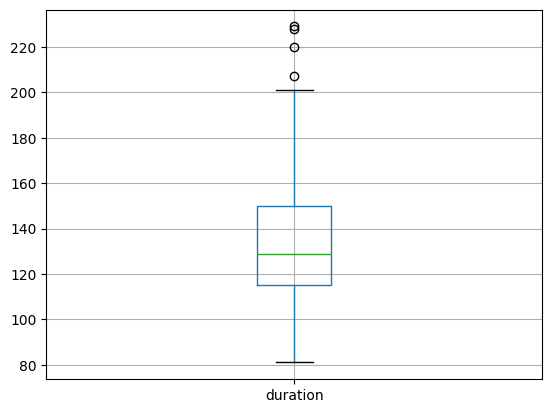

In [198]:
import matplotlib.pyplot as plt

df.boxplot(column="duration")
plt.show()

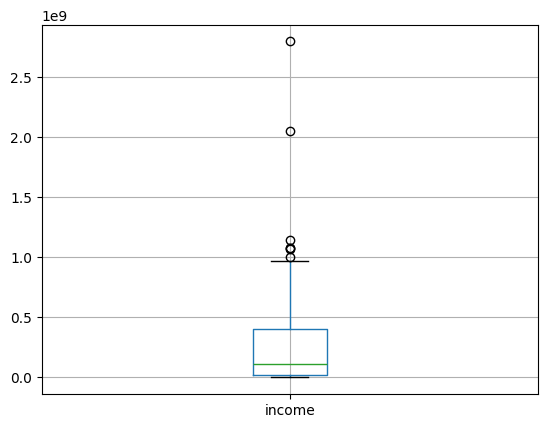

In [199]:
df.boxplot(column="income")
plt.show()

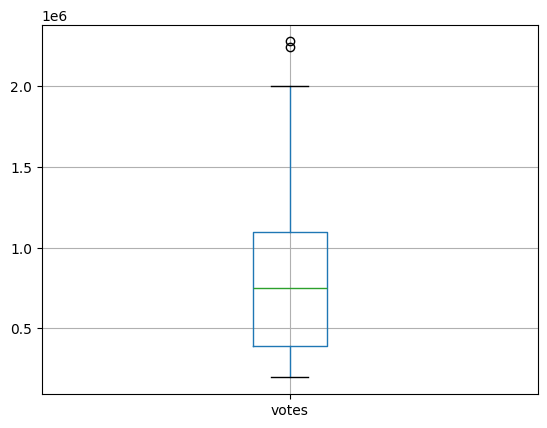

In [200]:
df.boxplot(column="votes")
plt.show()

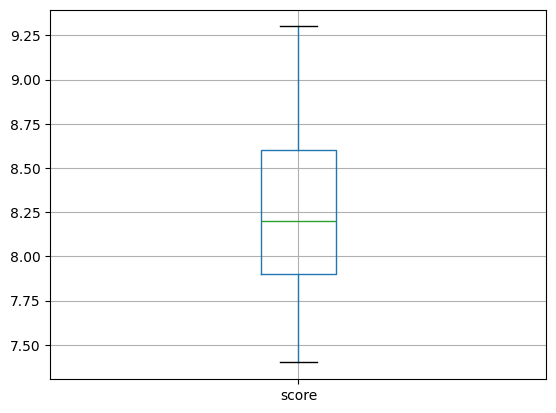

In [201]:
df.boxplot(column="score")
plt.show()

# 🧠 My Conclusion

👉 Income → more outliers

👉 Duration → some outliers

👉 Votes → some outliers

👉 Score → no outliers

🔍 Let’s Verify Using IQR Logic

📊 1. Income

From your stats:

Q1 = 23M

Q3 = 404M

Max = 2.79 Billion 🚨

👉 Huge gap → clearly:

✅ Income has strong outliers

📊 2. Duration

Q1 = 115

Q3 = 150

Upper ≈ 202

Max = 229

👉 Slightly above:

✅ Few outliers present

📊 3. Votes

Q1 = ~389K

Q3 = ~1.09M

Max = ~2.27M

👉 Not extreme jump:

✅ Mild outliers (not severe)

📊 4. Score

Range: 7.4 → 9.3

👉 Very tight range:

❌ No outliers

🎯 Final Conclusion (PROJECT LEVEL)


Outlier analysis using the IQR method revealed that the income column contains significant outliers due to large variations in movie earnings. The duration and votes columns showed minor outliers, while the score column exhibited a stable distribution with no noticeable outliers.

# Step 8(Project Completion)

Save cleaned dataset

In [202]:
df.to_csv("cleaned_imdb_dataset.csv", index=False)
df1 = pd.read_csv("cleaned_imdb_dataset.csv")
df1.head()

,imdb_title_id,original_title,release_year,genre,duration,country,content_rating,director,income,votes,score
0,tt0111161,The Shawshank Redemption,1995,Drama,142,USA,R,Frank Darabont,28815245,2278845,9.3
1,tt0068646,The Godfather,1995,"Crime, Drama",175,USA,R,Francis Ford Coppola,246120974,1572674,9.2
2,tt0468569,The Dark Knight,1995,"Action, Crime, Drama",152,US,PG-13,Christopher Nolan,1005455211,2241615,8.2
3,tt0071562,The Godfather: Part II,1975,"Crime, Drama",220,USA,R,Francis Ford Coppola,408035783,1098714,8.2
4,tt0110912,Pulp Fiction,1994,"Crime, Drama",129,USA,R,Quentin Tarantino,222831817,1780147,8.9


In [203]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   imdb_title_id   100 non-null    object 
 1   original_title  100 non-null    object 
 2   release_year    101 non-null    int64  
 3   genre           100 non-null    object 
 4   duration        101 non-null    int64  
 5   country         100 non-null    object 
 6   content_rating  101 non-null    object 
 7   director        100 non-null    object 
 8   income          101 non-null    int64  
 9   votes           101 non-null    int64  
 10  score           101 non-null    float64
dtypes: float64(1), int64(4), object(6)
memory usage: 8.8+ KB


In [204]:
df1.isnull().sum()

,0
imdb_title_id,1
original_title,1
release_year,0
genre,1
duration,0
country,1
content_rating,0
director,1
income,0
votes,0


🚀 Now Final Cleaning Step (Complete Project)

Option 1: Fill missing (Recommended)

In [205]:
df1["imdb_title_id"] = df1["imdb_title_id"].fillna("Unknown")
df1["original_title"] = df1["original_title"].fillna("Unknown")
df1["genre"] = df1["genre"].fillna("Unknown")
df1["country"] = df1["country"].fillna("Unknown")
df1["director"] = df1["director"].fillna("Unknown")

In [206]:
df1.isnull().sum()

,0
imdb_title_id,0
original_title,0
release_year,0
genre,0
duration,0
country,0
content_rating,0
director,0
income,0
votes,0
